**Bir nesnenin konumunu ve hızını takip eden 1D Alfa-Beta Filtresi için adım adım implementasyon**

**BÖLÜM 1: Giriş ve Sabitlerin Tanımlanması**

Alfa-Beta filtresi, karmaşık Kalman filtresinin en temel halidir. Bir nesnenin konumunu ($x$) ve hızını ($v$) tahmin eder.

Sistem iki temel adımdan oluşur:
- Tahmin (Prediction): Bir sonraki adımda nerede olacağız
- Güncelleme (Correction): Ölçüm geldikten sonra tahminimizi ne kadar düzelteceğiz?

Önce zaman adımını ($\Delta t$) ve filtre katsayılarını ($\alpha, \beta$) belirleyelim.

In [1]:
# zaman adımı (saniye)
dt = 1.0

# filtre katsayıları (0 ile 1 arasında)
# alpha: ölçüme ne kadar güveneceğimiza dair parametre
# beta: güncellemeleri ne kadar sert yapacağımıza dair parametre
alpha = 0.85
beta = 0.005

**BÖLÜM 2: Başlangıç Durumlarının (State) Tanımlanması**

Sistemin ilk andaki konum ve hız tahminini varsayarak başlıyoruz.

In [2]:
# İlk durum (T-1 anındaki durum)
x_est = 0.0 # tahmini konum
v_est = 0.0 # tahmini hız

**BÖLÜM 3: 1. Adım - Durum Tahmini (Prediction Step)**

Fizik kurallarına göre bir sonraki adımda ($k$) nerede olacağımızı tahmin ederiz:

$x_{pred} = x_{est} + v_{est} \cdot \Delta t$

$v_{pred} = v_{est}$ (Sabit hız varsayımı)

In [3]:
# buraya kod yazacağız
def predict(x, v, dt):
    x_pred = x + v * dt
    v_pred = v
    return x_pred, v_pred
# örnek test
x_pred, v_pred = predict(x_est, v_est, dt)
print(f"Tahmin edilen konum: {x_pred}, Tahmin edilen hız: {v_pred}")

Tahmin edilen konum: 0.0, Tahmin edilen hız: 0.0


**BÖLÜM 4: 2. Adım - Ölçüm Farkı (Residual / Inovation)**

Gerçek dünyadan bir radardan veya sensörden ölçüm ($z$) gelir. Ölçüm ile tahminimiz arasındaki fark kalıntı (residual) olarak adlandırılır:

$r = z - x_{pred}$

In [4]:
# Buraya kod yazacağız
def calculate_residual(z, x_pred):
    r = z - x_pred
    return r
# örnek test
z = 10.0  # Gerçek konum
r = calculate_residual(z, x_pred)
print(f"Kalıntı: {r}")

Kalıntı: 10.0


**BÖLÜM 5: 3. Adım - Durum Güncellemesi (Update Step)**

Kalıntıyı kullanarak hem konumu hem hızı güncelleriz:

$x_{est} = x_{pred} + \alpha \cdot r$

$v_{est} = v_{pred} + \left(\frac{\beta}{\Delta t}\right) \cdot r$

**BÖLÜM 6: Tüm Akışın Döngüye Alınması (Simülasyon)**

Şimdi tüm parçaları birleştirip gürültülü sensör verisi üzerinden simülasyon yapalım.

In [6]:
def update(x_pred, v_pred, r, dt, alpha, beta):
    x_est = x_pred + alpha * r
    v_est = v_pred + (beta / dt) * r
    return x_est, v_est

# durumları güncelleme
x_est, v_est = update(x_pred, v_pred, r, dt, alpha, beta)
# sonuçları yazdırma
print(f"Güncellenmiş konum: {x_est}, Güncellenmiş hız: {v_est}")

Güncellenmiş konum: 8.5, Güncellenmiş hız: 0.05


$\alpha$ ve $\beta$ katsayılarının filtre performansı üzerindeki etkisini (gürültü bastırma vs. gecikme/gecikmeli takip) doğrudan gözlemleyebileceğimiz Matplotlib görselleştirme alıştırması:

Şu iki temel senaryoyu inceleyebiliriz:

- Yüksek $\alpha$ / Yüksek $\beta$ (Örn: $\alpha=0.85, \beta=0.2$): Filtre, ölçümlere çok hızlı tepki verecek; ancak gürültüyü (noise) yeterince süzemeyecektir.
- Düşük $\alpha$ / Düşük $\beta$ (Örn: $\alpha=0.1, \beta=0.005$): Filtre gürültüyü harika bir şekilde süzecek; ancak gerçek hareketi takip etmekte gecikecektir (yani *lag* oluşacaktır).

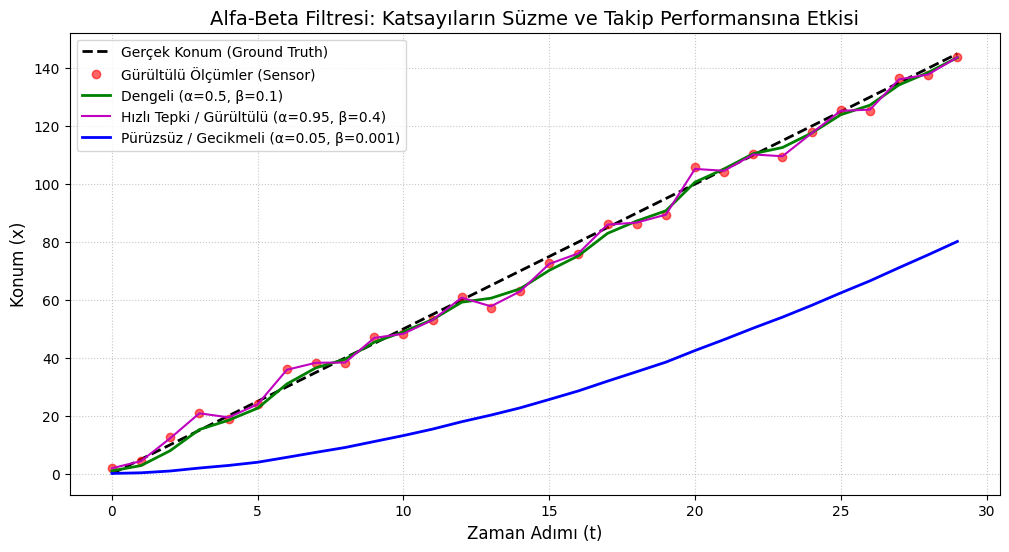

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. BÖLÜM: Veri Üretimi
dt = 1.0
num_steps = 30
np.random.seed(42)

# Gerçek konum: 5 m/s sabit hızla ilerleyen bir araç
true_velocity = 5.0
true_positions = np.array([0 + true_velocity * t for t in range(num_steps)])

# Sensör ölçümü: Gerçek konum + Normal Dağılımlı Gürültü (std = 4.0)
noise = np.random.normal(0, 4.0, size=num_steps)
measurements = true_positions + noise

# 2. BÖLÜM: Alfa-Beta Filtre Fonksiyonu
def run_alpha_beta_filter(measurements, alpha, beta, dt):
    x_est = 0.0
    v_est = 0.0
    filtered_x = []

    for z in measurements:
        # Predict
        x_pred = x_est + v_est * dt
        v_pred = v_est

        # Residual
        r = z - x_pred

        # Update
        x_est = x_pred + alpha * r
        v_est = v_pred + (beta / dt) * r

        filtered_x.append(x_est)

    return filtered_x

# 3. BÖLÜM: Farklı Katsayı Setlerinin Test Edilmesi
# Senaryo A: Dengeli (Balanced)
est_balanced = run_alpha_beta_filter(measurements, alpha=0.5, beta=0.1, dt=dt)

# Senaryo B: Ölçüme Aşırı Güvenen / Reaktif (High Alpha)
est_reactive = run_alpha_beta_filter(measurements, alpha=0.95, beta=0.4, dt=dt)

# Senaryo C: Aşırı Pürüzsüz / Gecikmeli (Low Alpha)
est_smooth = run_alpha_beta_filter(measurements, alpha=0.05, beta=0.001, dt=dt)

# 4. BÖLÜM: Grafiğin Çizdirilmesi
plt.figure(figsize=(12, 6))

# Gerçek ve Ölçülen Değerler
plt.plot(true_positions, 'k--', label='Gerçek Konum (Ground Truth)', linewidth=2)
plt.plot(measurements, 'ro', label='Gürültülü Ölçümler (Sensor)', alpha=0.6)

# Filtre Sonuçları
plt.plot(est_balanced, 'g-', label='Dengeli (α=0.5, β=0.1)', linewidth=2)
plt.plot(est_reactive, 'm-', label='Hızlı Tepki / Gürültülü (α=0.95, β=0.4)', linewidth=1.5)
plt.plot(est_smooth, 'b-', label='Pürüzsüz / Gecikmeli (α=0.05, β=0.001)', linewidth=2)

plt.title("Alfa-Beta Filtresi: Katsayıların Süzme ve Takip Performansına Etkisi", fontsize=14)
plt.xlabel("Zaman Adımı (t)", fontsize=12)
plt.ylabel("Konum (x)", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()